# pH, pOH, and acid/base equilibria: logarithms as a measurement unit

$[H^+]$ concentrations span roughly 14 orders of magnitude, from 1 M (strong
acid) down to $10^{-14}$ M (strong base) -- too wide a range to read off
comfortably as a raw number. $\mathrm{pH} = -\log_{10}[H^+]$ compresses that
range into a single-digit-to-teens scale, the SAME role logarithms play
elsewhere in engineering (decibels for intensity ratios, ENOB for a
digitizer's dynamic range) -- this notebook is about that log-compression
idea, applied to `dgs/acid_base_chemistry.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dgs.acid_base_chemistry import (
    pH_from_H_concentration, H_concentration_from_pH,
    pH_pOH_relationship, water_autoionization_check,
    strong_acid_pH, pKa_from_Ka, weak_acid_pH, henderson_hasselbalch,
    titration_curve, KW_25C,
)
print("loaded dgs.acid_base_chemistry")

loaded dgs.acid_base_chemistry


## Part 1 -- pH as a 14-decade compression

Plotting $[H^+]$ on a linear axis makes everything below $10^{-2}$ M look
like zero; plotting $-\log_{10}[H^+]$ spreads the whole physiologically and
chemically relevant range out evenly.

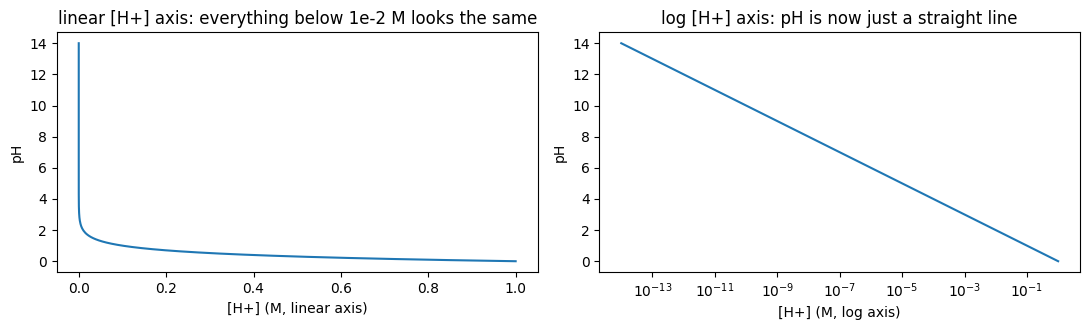

[H+]=1e-01 M -> pH=1.00 -> back to [H+]=1.00e-01 M
[H+]=1e-07 M -> pH=7.00 -> back to [H+]=1.00e-07 M
[H+]=1e-12 M -> pH=12.00 -> back to [H+]=1.00e-12 M


In [2]:
H_concs = np.logspace(0, -14, 200)  # 1 M down to 1e-14 M
pH_values = np.array([pH_from_H_concentration(h) for h in H_concs])

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].plot(H_concs, pH_values)
axs[0].set_xlabel('[H+] (M, linear axis)'); axs[0].set_ylabel('pH')
axs[0].set_title('linear [H+] axis: everything below 1e-2 M looks the same')
axs[1].semilogx(H_concs, pH_values)
axs[1].set_xlabel('[H+] (M, log axis)'); axs[1].set_ylabel('pH')
axs[1].set_title('log [H+] axis: pH is now just a straight line')
plt.tight_layout(); plt.show()

# round-trip check
for h in [1e-1, 1e-7, 1e-12]:
    ph = pH_from_H_concentration(h)
    back = H_concentration_from_pH(ph)
    print(f"[H+]={h:.0e} M -> pH={ph:.2f} -> back to [H+]={back:.2e} M")

## Part 2 -- pH + pOH = 14: water's autoionization constant

$K_w = [H^+][OH^-] = 10^{-14}$ at 25 C, fixed regardless of what's
dissolved -- so knowing pH always tells you pOH, and vice versa.

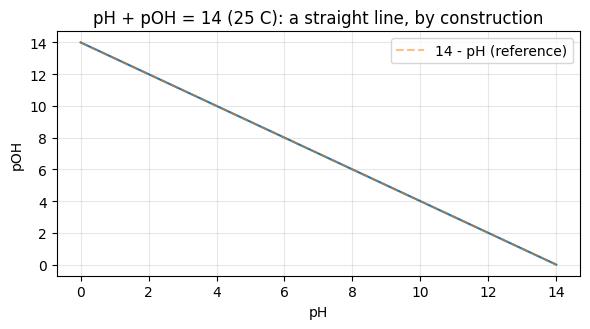

neutral water: [H+]*[OH-] = 1.00e-14  (Kw = 1.00e-14)  consistent=True


In [3]:
pH_range = np.linspace(0, 14, 100)
pOH_range = np.array([pH_pOH_relationship(pH=p)['pOH'] for p in pH_range])

plt.figure(figsize=(6, 3.4))
plt.plot(pH_range, pOH_range)
plt.plot(pH_range, 14 - pH_range, '--', alpha=0.5, label='14 - pH (reference)')
plt.xlabel('pH'); plt.ylabel('pOH'); plt.legend()
plt.title('pH + pOH = 14 (25 C): a straight line, by construction')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

check = water_autoionization_check(1e-7, 1e-7)
print(f"neutral water: [H+]*[OH-] = {check['product']:.2e}  (Kw = {check['Kw']:.2e})  "
      f"consistent={check['consistent']}")

## Part 3 -- strong vs. weak acid: same nominal concentration, different pH

A strong acid dissociates completely ($\mathrm{pH}=-\log_{10}C$); a weak
acid only partially dissociates, solved EXACTLY here via the equilibrium
quadratic (`weak_acid_pH`), not the common small-$x$ approximation.

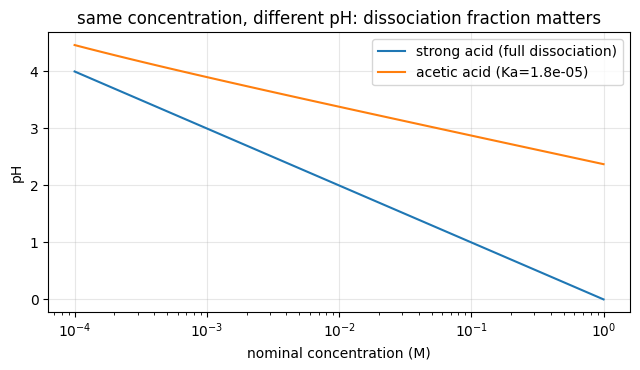

0.1 M acetic acid: pH=2.88, only 1.33% dissociated (vs. 0.1 M strong acid: pH=1.00)


In [4]:
concentrations = np.logspace(-4, 0, 40)
Ka_acetic = 1.8e-5  # acetic acid, a real, commonly tabulated Ka

strong_pH = np.array([strong_acid_pH(c) for c in concentrations])
weak_pH = np.array([weak_acid_pH(Ka_acetic, c)['pH'] for c in concentrations])

plt.figure(figsize=(6.5, 3.8))
plt.semilogx(concentrations, strong_pH, label='strong acid (full dissociation)')
plt.semilogx(concentrations, weak_pH, label=f'acetic acid (Ka={Ka_acetic:.1e})')
plt.xlabel('nominal concentration (M)'); plt.ylabel('pH')
plt.title('same concentration, different pH: dissociation fraction matters')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

result = weak_acid_pH(Ka_acetic, 0.1)
print(f"0.1 M acetic acid: pH={result['pH']:.2f}, "
      f"only {result['fraction_dissociated']*100:.2f}% dissociated "
      f"(vs. 0.1 M strong acid: pH={strong_acid_pH(0.1):.2f})")

## Part 4 -- Henderson-Hasselbalch: buffers, and why they resist pH change

$\mathrm{pH} = \mathrm{p}K_a + \log_{10}([A^-]/[HA])$ -- a direct
application of $\log_{10}(a/b) = \log_{10}a - \log_{10}b$ to the
equilibrium expression. Near a 1:1 base:acid ratio, pH barely moves as the
ratio shifts (the log term is near zero and changes slowly there) -- the
mechanism behind buffer capacity.

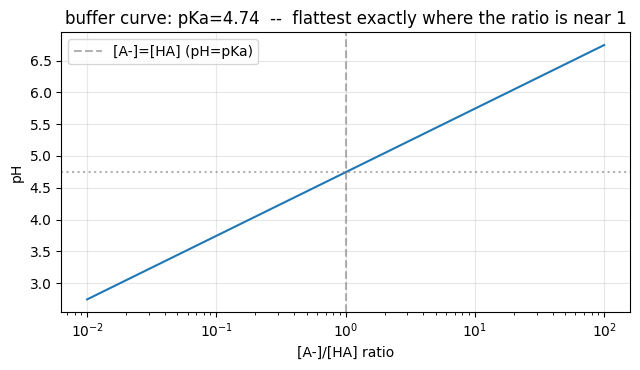

equal-concentration buffer: pH = 4.74  (should equal pKa=4.74)


In [5]:
pKa = pKa_from_Ka(Ka_acetic)
ratios = np.logspace(-2, 2, 200)  # base:acid from 100:1 acid-heavy to 100:1 base-heavy
pH_buffer = pKa + np.log10(ratios)

plt.figure(figsize=(6.5, 3.8))
plt.semilogx(ratios, pH_buffer)
plt.axvline(1.0, ls='--', color='gray', alpha=0.6, label='[A-]=[HA] (pH=pKa)')
plt.axhline(pKa, ls=':', color='gray', alpha=0.6)
plt.xlabel('[A-]/[HA] ratio'); plt.ylabel('pH')
plt.title(f'buffer curve: pKa={pKa:.2f}  --  flattest exactly where the ratio is near 1')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"equal-concentration buffer: pH = {henderson_hasselbalch(pKa, 0.1, 0.1):.2f}  (should equal pKa={pKa:.2f})")

## Part 5 -- strong acid / strong base titration curve

A real moles-balance simulation (`titration_curve`), not a schematic: at
each volume of titrant added, whichever species (acid or base) is in
excess sets the pH, with the characteristic sharp jump right at the
equivalence point where neither is in excess.

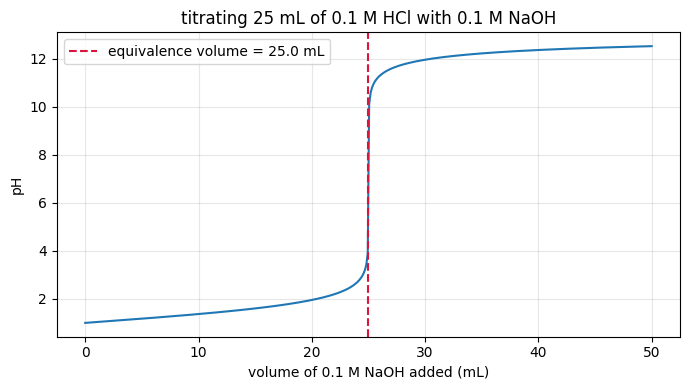

,fraction of equivalence,V_base (mL),pH
0,0.00,0.00,1.000000
1,0.50,12.50,1.478574
2,0.99,24.75,3.423246
3,1.00,25.00,3.901458
4,1.01,25.25,10.573489
5,1.50,37.50,12.300158


In [6]:
curve = titration_curve(C_acid=0.1, V_acid=25.0, C_base=0.1, n_points=400)

plt.figure(figsize=(7, 4))
plt.plot(curve['V_base'], curve['pH'])
plt.axvline(curve['equivalence_volume'], ls='--', color='crimson',
            label=f"equivalence volume = {curve['equivalence_volume']:.1f} mL")
plt.xlabel('volume of 0.1 M NaOH added (mL)'); plt.ylabel('pH')
plt.title('titrating 25 mL of 0.1 M HCl with 0.1 M NaOH')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

df = pd.DataFrame({
    'fraction of equivalence': [0.0, 0.5, 0.99, 1.0, 1.01, 1.5],
})
df['V_base (mL)'] = df['fraction of equivalence'] * curve['equivalence_volume']
df['pH'] = [curve['pH'][int(np.argmin(np.abs(curve['V_base'] - v)))] for v in df['V_base (mL)']]
display(df)

## Summary

| Concept | Function | Key result |
|---|---|---|
| pH as log-compression | `pH_from_H_concentration` | 14 decades of $[H^+]$ -> a single readable scale |
| Water autoionization | `pH_pOH_relationship` | pH + pOH = 14 always (25 C) |
| Strong vs. weak acid | `strong_acid_pH`, `weak_acid_pH` | 0.1 M acetic acid: pH 2.88, not pH 1.00 |
| Buffers | `henderson_hasselbalch` | pH = pKa at a 1:1 ratio; flattest there too |
| Titration | `titration_curve` | sharp pH jump exactly at the moles-balance point |

All five reuse `dgs/acid_base_chemistry.py`'s tested functions directly --
no new chemistry beyond that module.